# Legnini Evaluation

In [21]:
import scanpy as sc
import numpy as np

import InterScale as interscale
from InterScale.config import load_config
from graph_transformer_long_range_niches.pp import split_adata
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.evaluation import leiden_cluster_embeddings, plot_clustering_metrics, gene_rank_analysis
import InterScale._paths as path

from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

## Load pretrained models

In [2]:
RESULTS_DIR = '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/legnini23/model'

In [3]:
CFG = path.HOME_ICB.joinpath("src/config_files/Legnini23/legnini23_genes_sample_GlobalModel.yaml")
FIG_DIR = path.HOME_ICB.joinpath("figures/legnini23/")

In [4]:
cfg = load_config(CFG)

In [5]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [6]:
adata.obsm['spatial']

array([[2369.601, 1167.102],
       [4930.774, 1151.607],
       [2274.517, 1143.662],
       ...,
       [3625.728, 7206.087],
       [3170.51 , 7260.791],
       [3495.327, 7333.994]])

In [10]:
interscale.model.LocalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
local_model = interscale.model.LocalModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = False)
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
combined_model = interscale.model.CombinedModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = True)

Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


## Inference 

In [36]:
sub_adata = adata[adata.obs['condition'] == 'Ctrl']

In [37]:
result = local_model.get_model_output(sub_adata, prefix = 'local')

INFO     Received view of anndata, making copy.                                                                    
call new


In [38]:
result = combined_model.get_model_output(result, prefix = 'combined')

call new
1702
2001
1641
1959
1985
1644


In [39]:
result

AnnData object with n_obs × n_vars = 11796 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_key', 'combined_cls'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', 'local_local_emb', 'local_decoder_weight', 'combined_local_emb', 'combined_global_emb', 'combined_attn_matrix', 'combined_decoder_weight'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', 'local_y_pred', 'combined_y_pred'

# Compare Local and Global embedding

First we check whether the local and global embedding capture different structures.

Removing 870 observations with all-NaN global embeddings
New shape: (10926, 88)


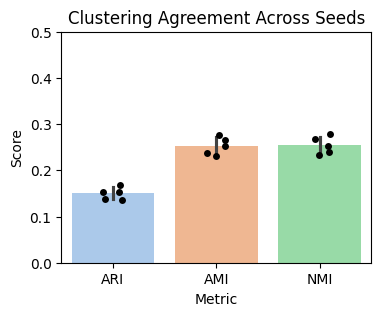

{'ARI': [0.16891803311599207,
  0.15357700181107067,
  0.1534301047028011,
  0.13834934257785084,
  0.13645396368437473],
 'AMI': [0.27651485700261,
  0.26629579729359626,
  0.2516578262700636,
  0.23175892595725917,
  0.23768597714882683],
 'NMI': [0.2780279348861868,
  0.2675882904338921,
  0.25273168497299964,
  0.2333699896976556,
  0.23877245591281065]}

In [40]:
leiden_cluster_embeddings(result)

## Gene Rank analysis

Top 5 genes for local_y_pred model:
       gene        r2    r2_log  r2_rank
47    MNX1  0.025806  0.025478     88.0
25   FOXA1  0.004345  0.004336     87.0
53  NKX2.1  0.000000  0.000000     85.5
87   TREM2  0.000000  0.000000     85.5
20   EOMES -0.001446 -0.001447     84.0
Top 5 genes for combined_y_pred model:
       gene        r2    r2_log  r2_rank
73     SHH  0.004953  0.004941     88.0
53  NKX2.1  0.000000  0.000000     86.5
87   TREM2  0.000000  0.000000     86.5
22     FOS -0.002726 -0.002729     85.0
67    PER3 -0.010552 -0.010608     84.0
Figure saved to: /home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/legnini23/gene_rank_analysis_Ctrl.png


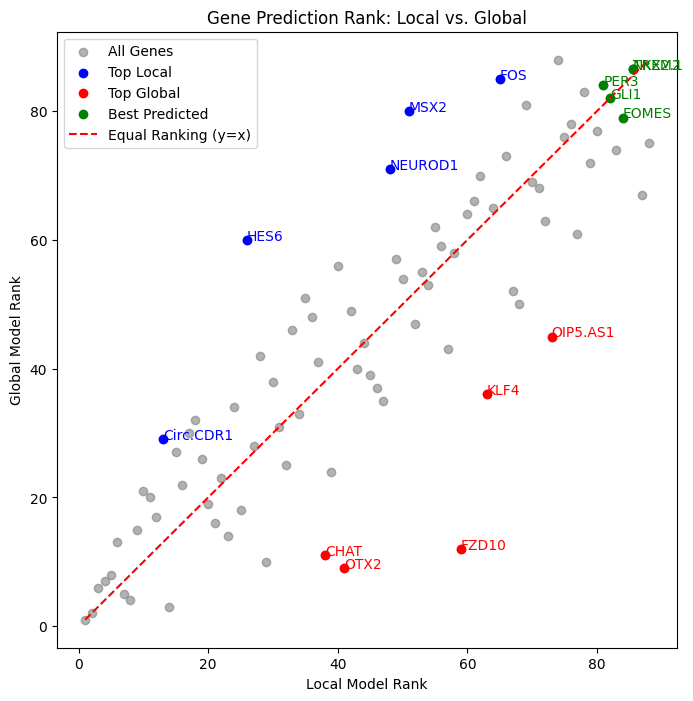

(         gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 34       HES6        26.0         60.0            -34.0      43.0
 49       MSX2        51.0         80.0            -29.0      65.5
 51    NEUROD1        48.0         71.0            -23.0      59.5
 22        FOS        65.0         85.0            -20.0      75.0
 13  Circ.CDR1        13.0         29.0            -16.0      21.0,
         gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 28     FZD10        59.0         12.0             47.0      35.5
 63      OTX2        41.0          9.0             32.0      25.0
 59  OIP5.AS1        73.0         45.0             28.0      59.0
 11      CHAT        38.0         11.0             27.0      24.5
 44      KLF4        63.0         36.0             27.0      49.5,
       gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 53  NKX2.1        85.5         86.5             -1.0      86.0
 87   TREM2        85.5         86.5             -1.0      86.0
 67    P

In [41]:
gene_rank_analysis(result,
                   layers_local_pred = 'local_y_pred',
                   layers_global_pred = 'combined_y_pred',
                   top_n = 5,
                   plot_result = True,
                   return_top_genes = True,
                  save_dir = FIG_DIR,
                  post_fix = 'Ctrl')